Drug Response Classification

Data Preprocessing & Splitting

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('/content/Pharma_Industry.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['Drug Response'])
y = df['Drug Response']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Training a Classification Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

Performance Evaluation

In [ ]:
# Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7800
ROC-AUC Score: 0.8283

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        48
           1       0.79      0.79      0.79        52

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.78      0.78      0.78       100



Feature Importance Analysis

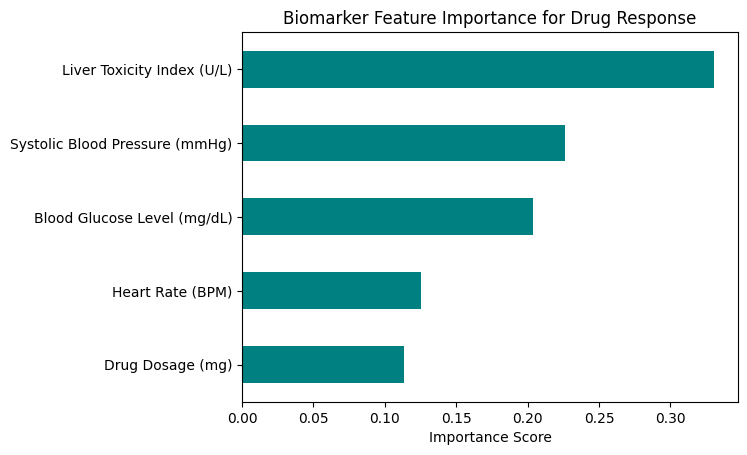

In [ ]:
import matplotlib.pyplot as plt

# Extract and plot feature importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='teal')
plt.title('Biomarker Feature Importance for Drug Response')
plt.xlabel('Importance Score')
plt.show()


Exploratory Data Analysis (EDA) & Data Visualization

Dataset Shape: (500, 6)

Missing Values:
 Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

Class Distribution:
 Drug Response
1    0.52
0    0.48
Name: proportion, dtype: float64


/tmp/ipykernel_3990/1277852299.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Drug Response', data=df, palette='Set2')


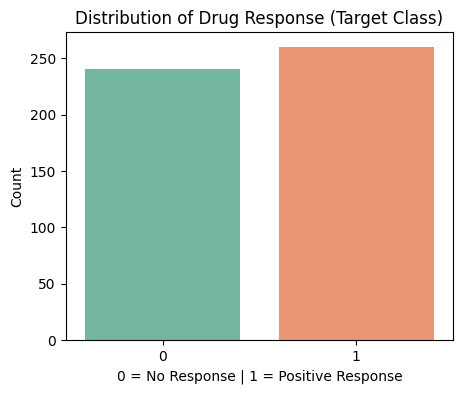

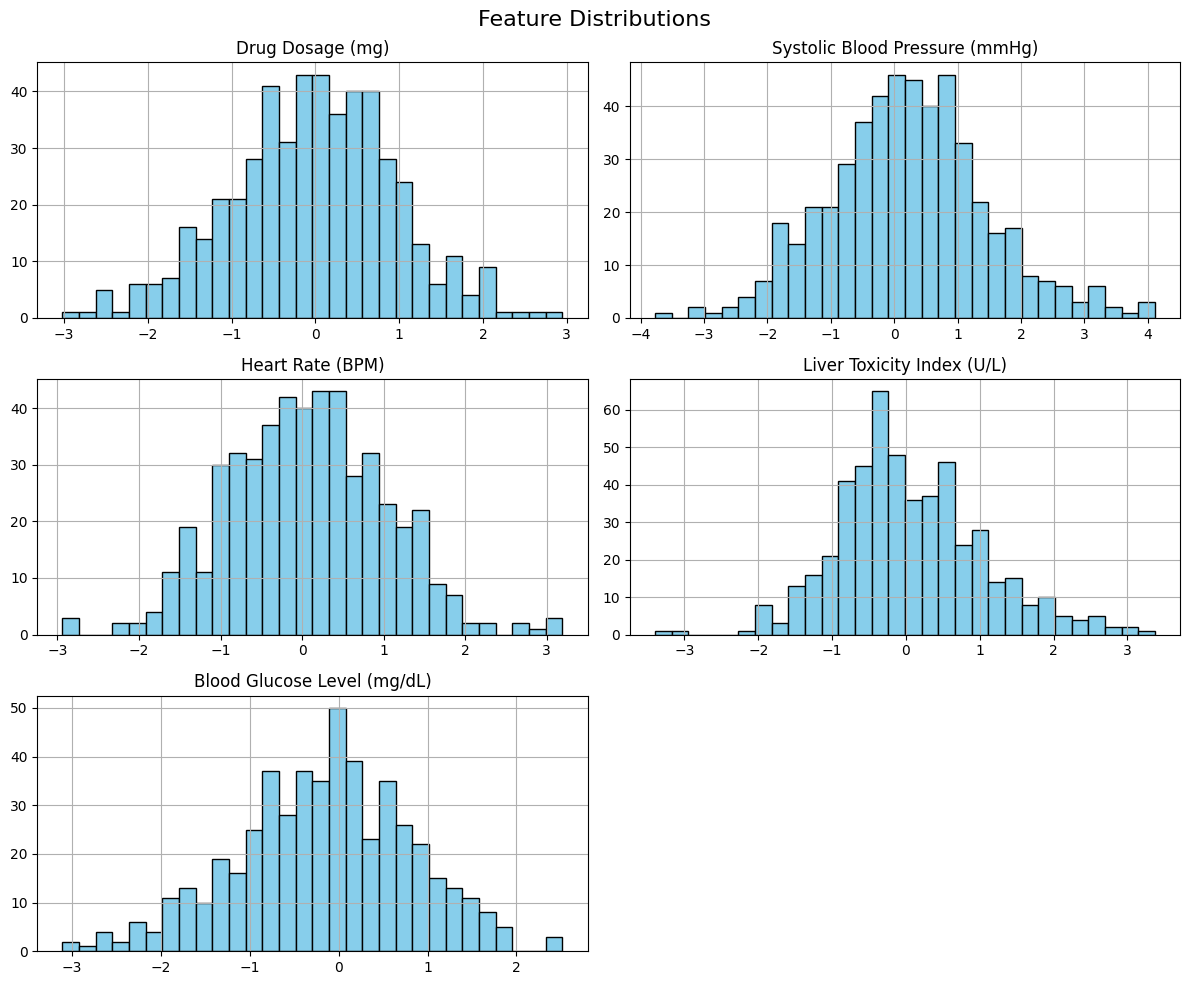

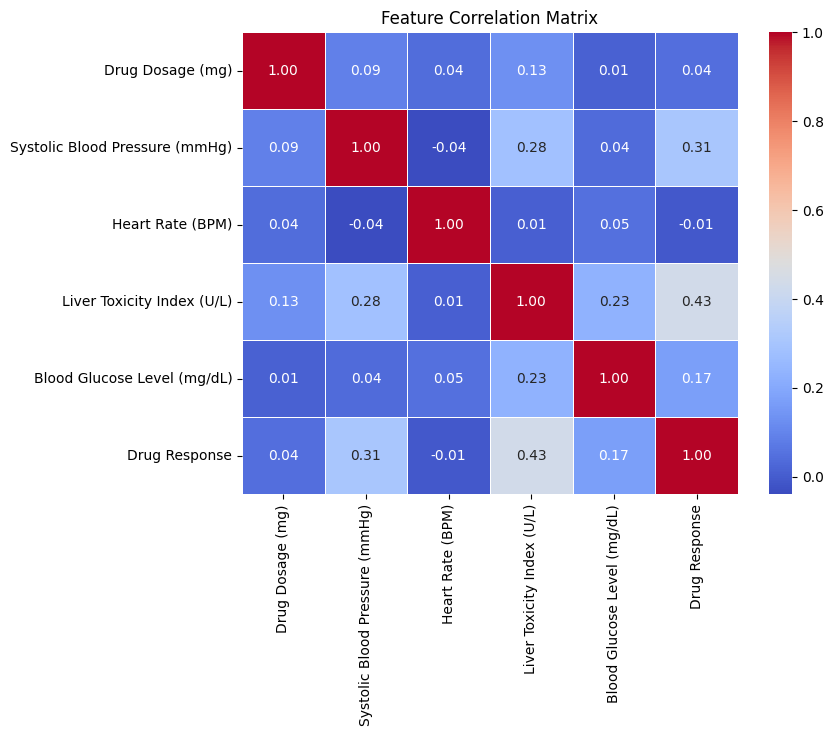

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Pharma_Industry.csv')

# 1. Fundamental Data Exploration
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['Drug Response'].value_counts(normalize=True))

# 2. Visualize Class Distribution (Imbalance check)
plt.figure(figsize=(5, 4))
sns.countplot(x='Drug Response', data=df, palette='Set2')
plt.title('Distribution of Drug Response (Target Class)')
plt.xlabel('0 = No Response | 1 = Positive Response')
plt.ylabel('Count')
plt.show()

# 3. Feature Distributions (Histograms / Density plots)
df.drop(columns=['Drug Response']).hist(bins=30, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Feature Correlations
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

Data Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['Drug Response'])
y = df['Drug Response']

# Split data into 80% training and 20% testing
# Using stratify ensures both sets have the exact same ratio of 0s and 1s
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 400 samples
Testing set size: 100 samples


SVM Implementation & Result Visualization

Baseline Linear SVM Accuracy: 0.7200

Confusion Matrix:
[[37 11]
 [17 35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



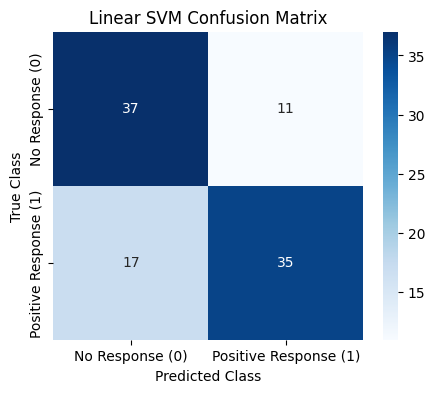

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Implement a basic SVM classifier
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)

# Predict on test data
y_pred = svm_linear.predict(X_test)

# Evaluate performance
print(f"Baseline Linear SVM Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Task 5: Visualization of Results via Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Response (0)', 'Positive Response (1)'],
            yticklabels=['No Response (0)', 'Positive Response (1)'])
plt.title('Linear SVM Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

Parameter Tuning, Optimization, and Comparison


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define different kernels and hyperparameter grids to experiment with
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1, 1]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2, 3, 4]}
]

# Grid Search with 5-Fold Cross-Validation
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)

# Evaluate the optimized model
best_svm = grid_search.best_estimator_
y_opt_pred = best_svm.predict(X_test)

print(f"\nOptimized SVM Accuracy: {accuracy_score(y_test, y_opt_pred):.4f}")
print("\nOptimized Classification Report:")
print(classification_report(y_test, y_opt_pred))

Best Parameters Found: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Optimized SVM Accuracy: 0.7200

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.67      0.70        48
           1       0.71      0.77      0.74        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100

